# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
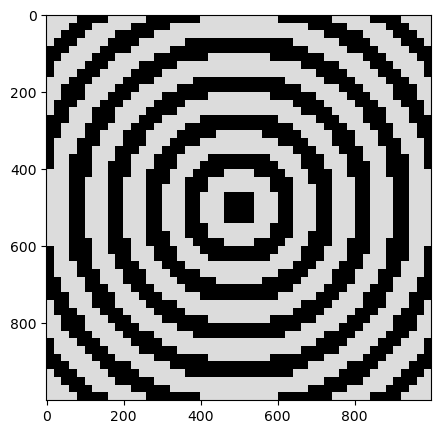


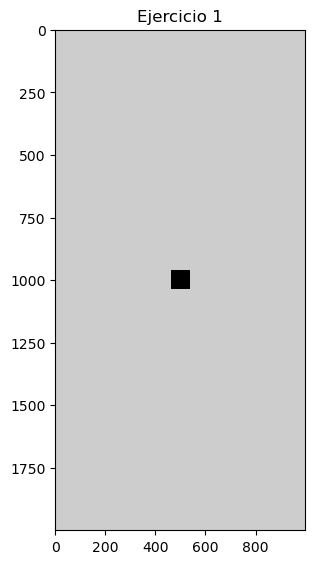

Guardada en: salidas\ejercicio1_diana.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
##gg nomas
alto, ancho = 2000, 1000
fondo = 205
paso = 65

img = np.full((alto, ancho), fondo, dtype=np.uint8)

y, x = np.indices((alto, ancho))
cx, cy = ancho // 2, alto // 2
d = np.maximum(np.abs(x - cx), np.abs(y - cy))

m = 37
img[cy - m:cy + m, cx - m:cx + m] = 0

os.makedirs("salidas", exist_ok=True)
ruta = os.path.join("salidas", "ejercicio1_diana.png")
cv2.imwrite(ruta, img)

plt.figure(figsize=(6.5, 6.5))
plt.imshow(img, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
plt.title("Ejercicio 1")
plt.show()

print("Guardada en:", ruta)

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
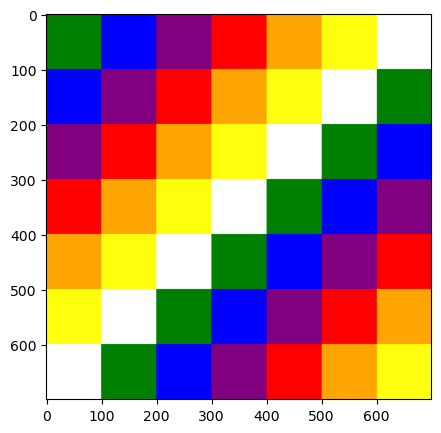

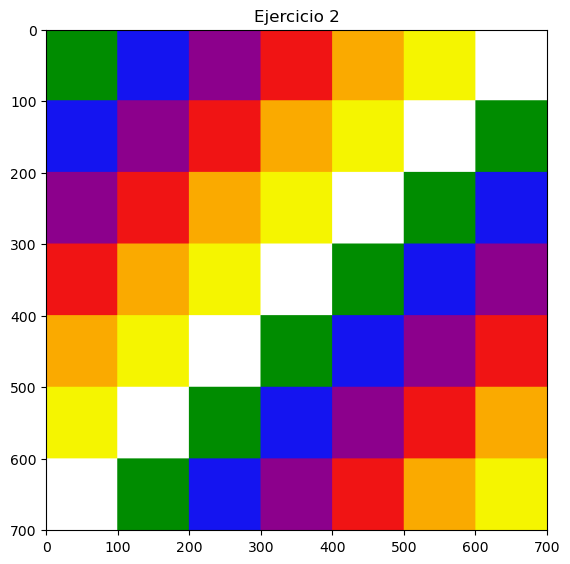

Guardada en: salidas\ejercicio2_patron_colores.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Ejercicio 2 - patron de bloques de colores
n = 7              
tam = 100          
alto = n * tam
ancho = n * tam

colores = [
    (0, 140, 0),      # verde
    (20, 20, 240),    # azuñ
    (140, 0, 140),    # morado
    (240, 20, 20),    # rojo
    (250, 170, 0),    # naranja
    (245, 245, 0),    # amarillo
    (255, 255, 255)   # blanco
]

img2 = np.zeros((alto, ancho, 3), dtype=np.uint8)

for fila in range(n):
    for col in range(n):
        color = colores[(fila + col) % n]
        y0, y1 = fila * tam, (fila + 1) * tam
        x0, x1 = col * tam, (col + 1) * tam
        img2[y0:y1, x0:x1] = color

os.makedirs("salidas", exist_ok=True)
ruta2 = os.path.join("salidas", "ejercicio2_patron_colores.png")
cv2.imwrite(ruta2, cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(6.5, 6.5))
plt.imshow(img2)
plt.title("Ejercicio 2")
plt.xlim(0, ancho)
plt.ylim(alto, 0)
plt.show()

print("Guardada en:", ruta2)

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

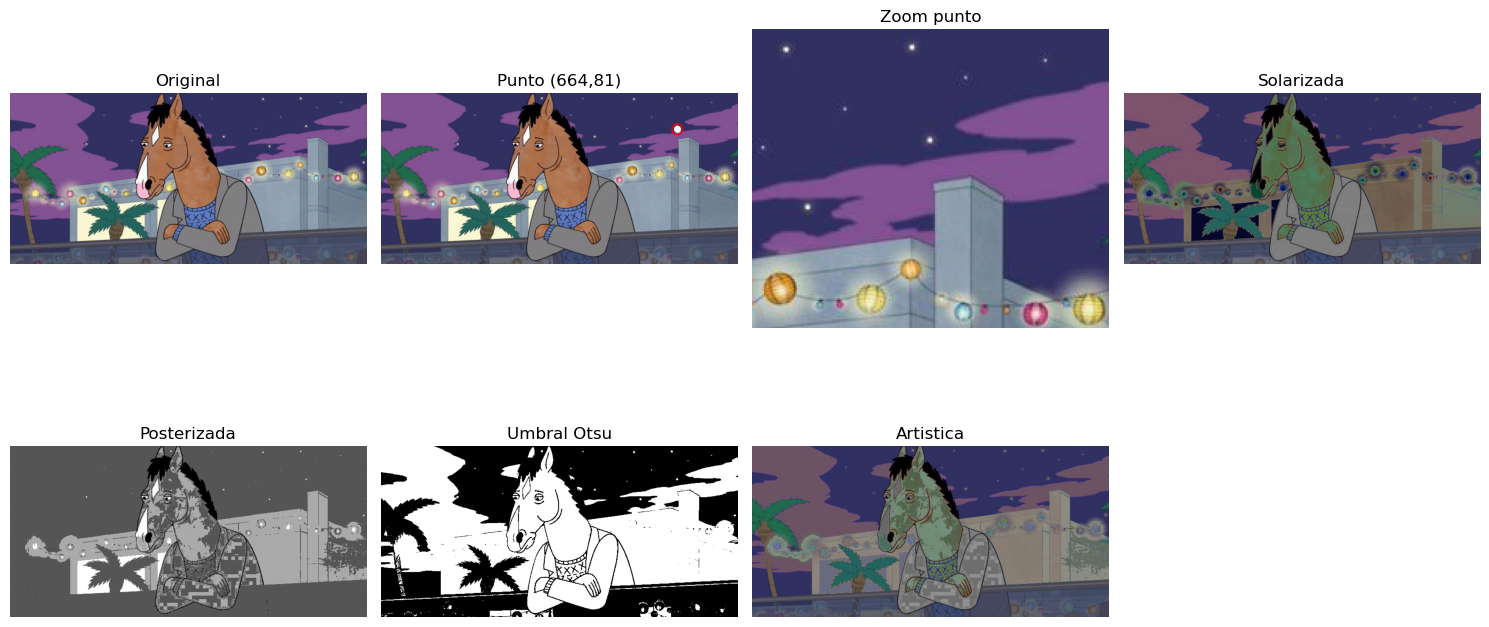

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)

def posterizar(imagen, niveles):
    factor_escala = 255 / niveles
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return img_pos.astype(np.uint8)

imagen = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
alto, ancho = img_rgb.shape[:2]

x = np.random.randint(0, ancho)
y = np.random.randint(0, alto)
img_punto = img_rgb.copy()
cv2.circle(img_punto, (x, y), 8, (255, 255, 255), -1)
cv2.circle(img_punto, (x, y), 12, (255, 0, 0), 2)

r = 120
y1, y2 = max(0, y - r), min(alto, y + r)
x1, x2 = max(0, x - r), min(ancho, x + r)
zoom_punto = img_rgb[y1:y2, x1:x2]

solarizada = solarizar(img_rgb, 127)
posterizada = posterizar(img_gray, 3)
_, umbral_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
mezcla = cv2.addWeighted(solarizada, 0.6, cv2.cvtColor(posterizada, cv2.COLOR_GRAY2RGB), 0.4, 0)
artistica = np.where(umbral_otsu[:, :, None] > 0, mezcla, img_rgb).astype(np.uint8)

os.makedirs('salidas', exist_ok=True)
resultados = {
    'e3_original.png': img_rgb,
    'e3_punto_interes.png': img_punto,
    'e3_zoom_punto.png': zoom_punto,
    'e3_solarizada.png': solarizada,
    'e3_posterizada.png': posterizada,
    'e3_umbral_otsu.png': umbral_otsu,
    'e3_artistica.png': artistica
}

for nombre, img in resultados.items():
    ruta = os.path.join('salidas', nombre)
    if img.ndim == 2:
        cv2.imwrite(ruta, img)
    else:
        cv2.imwrite(ruta, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(15, 8))
plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_punto)
plt.title(f'Punto ({x},{y})')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(zoom_punto)
plt.title('Zoom punto')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(solarizada)
plt.title('Solarizada')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(posterizada, cmap='gray')
plt.title('Posterizada')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(umbral_otsu, cmap='gray')
plt.title('Umbral Otsu')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(artistica)
plt.title('Artistica')
plt.axis('off')

plt.tight_layout()
plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

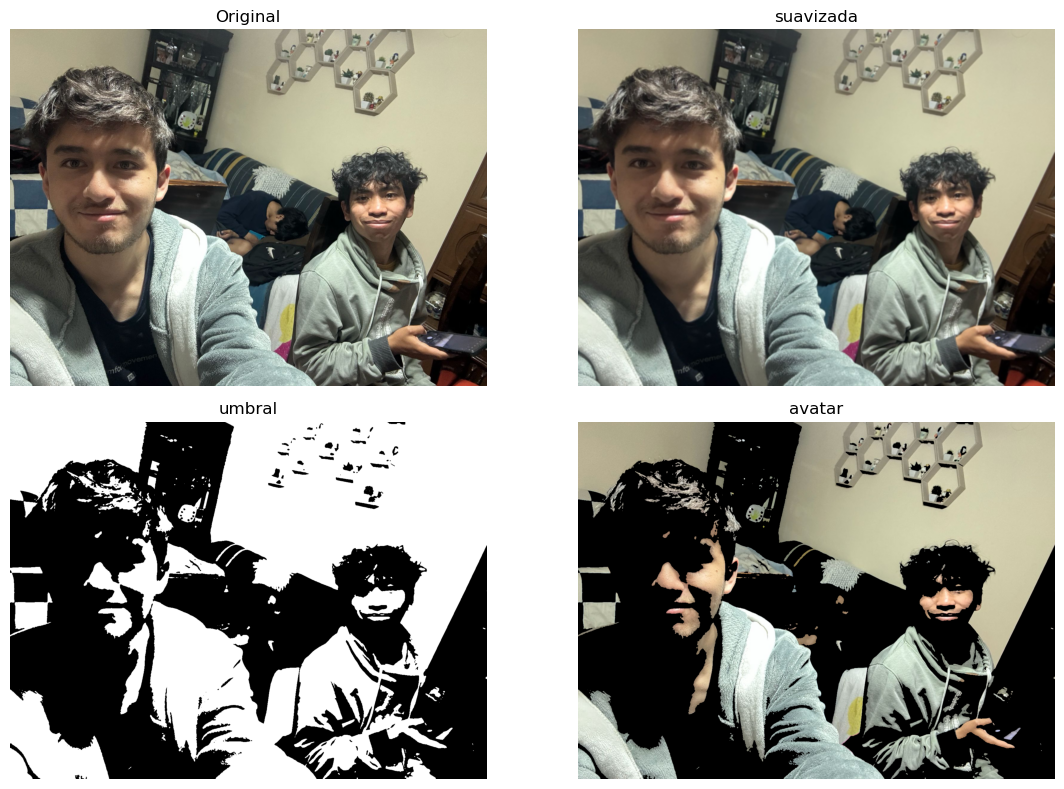

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_bgr = cv2.imread("cv1.jpeg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

suave = cv2.GaussianBlur(img_rgb, (7, 7), 0)
gris = cv2.cvtColor(suave, cv2.COLOR_RGB2GRAY)
_, bordes = cv2.threshold(gris, 120, 255, cv2.THRESH_BINARY)
avatar = cv2.bitwise_and(img_rgb, img_rgb, mask=bordes)



os.makedirs("salidas", exist_ok=True)
cv2.imwrite("salidas/e4_original.png", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite("salidas/e4_suavizada.png", cv2.cvtColor(suave, cv2.COLOR_RGB2BGR))
cv2.imwrite("salidas/e4_umbral.png", bordes)
cv2.imwrite("salidas/e4_avatar.png", cv2.cvtColor(avatar, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(suave)
plt.title("suavizada")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bordes, cmap="gray")
plt.title("umbral")
plt.axis("off")
plt.subplot(2, 2, 4)
plt.imshow(avatar)
plt.title("avatar")
plt.axis("off")

plt.tight_layout()
plt.show()